# LISA Fisher Forecast for a First-Order Phase Transition Signal

This notebook reproduces the LISA Fisher-matrix analysis for a stochastic gravitational-wave background generated by a first-order phase transition. The signal model includes sound-wave and turbulence contributions

The Fisher analysis is performed for the two logarithmic parameters
$\theta = \left(\ln \alpha,\ \ln(\beta/H_*)\right)$
while holding the transition temperature $T_*$ and bubble wall velocity $v_w$ fixed.

The notebook is organized as follows:

1. Define the source model, LISA effective noise model, SNR, and Fisher functions.
2. Choose LISA-band fiducial models by placing the sound-wave peak in the mHz band.
3. Tune $\alpha$ to selected target SNR values.
4. Compute the two-parameter Fisher matrices.
5. Generate the spectrum, sensitivity, SNR-contour, and Fisher-ellipse figures.

## Core LISA analysis functions

Define the functions used for the LISA Fisher forecast.

In [1]:
import numpy as np
# Cosmology constants
# ----------------------------
MPC_IN_M = 3.085677581491367e22
H0_KM_S_MPC = 67.4
H0_SI = (H0_KM_S_MPC * 1000.0) / MPC_IN_M  # s^-1
C_SI = 299792458.0

# S_h(f) = (3 H0^2 / (10 pi^2)) * Omega(f) / f^3
SH_PREFAC = 3.0 * H0_SI**2 / (10.0 * np.pi**2)



def sh_from_omega(f_hz, omega):
    """
    Convert the dimensionless gravitational-wave energy density spectrum
    Omega_GW(f) into the strain power spectral density S_h(f).

    The conversion used here is

    S_h(f) = [3 H0^2 / (10 pi^2)] * Omega_GW(f) / f^3,

    where H0 is expressed in SI units.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    omega : array_like
        Dimensionless gravitational-wave energy density spectrum Omega_GW(f).

    Returns
    -------
    array_like
        Strain power spectral density S_h(f) in Hz^{-1}.
    """
    f = np.asarray(f_hz, dtype=float)
    return SH_PREFAC * np.asarray(omega, dtype=float) / (f**3)

# ----------------------------
# LISA effective strain noise PSD
def psd_lisa_effective(f_hz, include_confusion=False):
    """
    Evaluate the effective LISA strain-noise power spectral density.

    This function implements a sky-averaged LISA sensitivity
    model suitable for the DECIGO-style cross-correlation Fisher workflow used
    in this notebook. The returned quantity is an effective strain-noise PSD
    $S_n(f)$ with units of Hz$^{-1}$.

    The model includes optical metrology noise and acceleration noise. If
    include_confusion=True, an analytic Galactic confusion foreground term is
    added to the instrumental noise.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz. All frequencies must be positive.
    include_confusion : bool, optional
        If True, include an analytic Galactic confusion-noise contribution.
        Default is False.

    Returns
    -------
    array_like
        Effective LISA strain-noise power spectral density $S_n(f)$ in Hz$^{-1}$.

    Raises
    ------
    ValueError
        Raised if any input frequency is non-positive.
    """
    f = np.asarray(f_hz, dtype=float)
    if np.any(f <= 0):
        raise ValueError("Frequencies must be positive.")

    # LISA arm length
    L = 2.5e9  # m
    fstar = C_SI / (2.0 * np.pi * L)

    # Optical metrology noise (displacement), [m^2/Hz]
    P_oms = (1.5e-11)**2 * (1.0 + (2.0e-3 / f)**4)

    # Acceleration noise, [m^2 s^-4 / Hz]
    P_acc = (3.0e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

    # Effective strain noise PSD (RCL-style forecast usage)
    S_n = (10.0 / (3.0 * L**2)) * (
        P_oms + 2.0 * (1.0 + np.cos(f / fstar)**2) * P_acc / (2.0 * np.pi * f)**4
    ) * (1.0 + 0.6 * (f / fstar)**2)

    if include_confusion:
        # Common 4-year-type analytic fit used in forecast literature (optional)
        A = 9e-45
        alpha = 0.138
        beta = -221.0
        kappa = 521.0
        gamma = 1680.0
        fk = 0.00113  # Hz
        S_conf = (
            A * f**(-7.0/3.0)
            * np.exp(-f**alpha + beta * f * np.sin(kappa * f))
            * (1.0 + np.tanh(gamma * (fk - f)))
        )
        S_n = S_n + S_conf

    return S_n

# ----------------------------
# PT spectrum: Weir-style sound + turbulence 
def omega_pt_weir_sw_turb(
    f_hz,
    *,
    alpha,
    beta_over_H,
    Tstar_GeV,
    vw,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    
    def omega_pt_weir_sw_turb(
    f_hz,
    *,
    alpha,
    beta_over_H,
    Tstar_GeV,
    vw,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):"""
    Compute the stochastic gravitational-wave spectrum from a first-order
    phase transition using sound-wave and turbulence contributions.

    This implementation neglects the scalar-field bubble-collision/envelope
    contribution, so the total signal is modeled as

    Omega_GW(f) = Omega_sw(f) + Omega_turb(f).

    The function returns Omega_GW(f), not h^2 Omega_GW(f). The conversion from
    h^2 Omega_GW to Omega_GW is done using the value of h implied by
    H0_KM_S_MPC.

    The model uses the benchmark efficiency closure

    kappa_f = alpha / (0.73 + 0.083 sqrt(alpha) + alpha),

    and, unless Uf is supplied directly,

    Uf^2 = (3/4) * kappa_f * alpha / (1 + alpha).

    The turbulence efficiency is taken to be

    kappa_turb = turb_fraction * kappa_f.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    alpha : float
        Phase-transition strength parameter.
    beta_over_H : float
        Inverse duration of the transition, beta/H_*.
    Tstar_GeV : float
        Transition temperature T_* in GeV.
    vw : float
        Bubble wall velocity. Must satisfy 0 < vw <= 1.
    gstar : float, optional
        Effective number of relativistic degrees of freedom. Default is 106.75.
    Uf : float or None, optional
        RMS fluid velocity. If None, the benchmark closure above is used.
    zp : float, optional
        Numerical factor entering the sound-wave peak frequency. Default is 6.9.
    Gamma : float, optional
        Adiabatic index. Default is 4/3.
    turb_fraction : float, optional
        Fraction of the bulk fluid efficiency assigned to turbulence.
        Default is 0.05.

    Returns
    -------
    array_like
        Total dimensionless gravitational-wave spectrum Omega_GW(f).

    Raises
    ------
    ValueError
        Raised if alpha, beta_over_H, or Tstar_GeV are non-positive, or if
        vw is outside the interval 0 < vw <= 1.
    """
    f = np.asarray(f_hz, dtype=float)
    if not (alpha > 0 and beta_over_H > 0 and Tstar_GeV > 0 and 0 < vw <= 1):
        raise ValueError("Unphysical phase-transition parameters.")

    H_over_beta = 1.0 / beta_over_H

    # efficiency closure (benchmark approximation)
    kappa_f = alpha / (0.73 + 0.083 * np.sqrt(alpha) + alpha)
    if Uf is None:
        Uf2 = (3.0 / 4.0) * (kappa_f * alpha / (1.0 + alpha))
        Uf = float(np.sqrt(max(Uf2, 0.0)))
    kappa_turb = turb_fraction * kappa_f

    # sound-wave characteristic freq and shape
    f_sw = 8.9e-6 * (beta_over_H / vw) * (zp / 10.0) * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)
    x = f / f_sw
    S_sw = (x**3) * (7.0 / (4.0 + 3.0 * x**2))**(7.0/2.0)

    h2Omega_sw = (
        8.5e-6
        * (100.0 / gstar)**(1.0/3.0)
        * (Gamma**2)
        * (Uf**4)
        * H_over_beta
        * vw
        * S_sw
    )

    # turbulence characteristic freq and shape
    f_turb = 27.0e-6 * (beta_over_H / vw) * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)
    h_star = 16.5e-6 * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)

    y = f / f_turb
    S_turb = (y**3) / ((1.0 + y)**(11.0/3.0) * (1.0 + 8.0*np.pi*f/h_star))

    h2Omega_turb = (
        3.35e-4
        * H_over_beta
        * (kappa_turb * alpha / (1.0 + alpha))**(3.0/2.0)
        * (100.0 / gstar)**(1.0/3.0)
        * vw
        * S_turb
    )

    # Convert h^2 Omega -> Omega
    h = H0_KM_S_MPC / 100.0
    return (h2Omega_sw + h2Omega_turb) / (h**2)

def omega_pt_lnparams(f_hz, ln_alpha, ln_beta_over_H, ln_Tstar, ln_vw, **kwargs):
    """
    Evaluate the phase-transition spectrum using logarithmic parameters.

    This wrapper is used in the Fisher calculation, where finite-difference
    derivatives are taken with respect to logarithmic parameters. The physical
    parameters are recovered through

        alpha       = exp(ln_alpha),
        beta/H_*   = exp(ln_beta_over_H),
        T_*        = exp(ln_Tstar),
        v_w        = exp(ln_vw).

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    ln_alpha : float
        Natural logarithm of the phase-transition strength alpha.
    ln_beta_over_H : float
        Natural logarithm of beta/H_*.
    ln_Tstar : float
        Natural logarithm of the transition temperature T_* in GeV.
    ln_vw : float
        Natural logarithm of the bubble wall velocity v_w.
    **kwargs
        Additional keyword arguments passed to omega_pt_weir_sw_turb.

    Returns
    -------
    array_like
        Total dimensionless gravitational-wave spectrum Omega_GW(f).
    """
    return omega_pt_weir_sw_turb(
        f_hz,
        alpha=float(np.exp(ln_alpha)),
        beta_over_H=float(np.exp(ln_beta_over_H)),
        Tstar_GeV=float(np.exp(ln_Tstar)),
        vw=float(np.exp(ln_vw)),
        **kwargs
    )

# ----------------------------
# Helpers: characteristic frequencies + T_* solver for target f_sw
def pt_characteristic_freqs(*, beta_over_H, Tstar_GeV, vw, gstar=106.75, zp=6.9):
    """
    Compute the characteristic sound-wave and turbulence frequencies.

    These are the same characteristic frequencies used inside
    omega_pt_weir_sw_turb. The sound-wave frequency f_sw is used to place the
    phase-transition signal in the LISA band by solving for T_* in the next
    helper function.

    Parameters
    ----------
    beta_over_H : float
        Inverse duration of the transition, beta/H_*.
    Tstar_GeV : float
        Transition temperature T_* in GeV.
    vw : float
        Bubble wall velocity.
    gstar : float, optional
        Effective number of relativistic degrees of freedom. Default is 106.75.
    zp : float, optional
        Numerical factor entering the sound-wave peak frequency. Default is 6.9.

    Returns
    -------
    f_sw : float
        Sound-wave characteristic frequency in Hz.
    f_turb : float
        Turbulence characteristic frequency in Hz.
    """
    f_sw = 8.9e-6 * (beta_over_H / vw) * (zp / 10.0) * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)
    f_turb = 27.0e-6 * (beta_over_H / vw) * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)
    return float(f_sw), float(f_turb)

def solve_Tstar_for_target_fsw(
    *,
    f_sw_target_Hz,
    beta_over_H,
    vw,
    gstar=106.75,
    zp=6.9,
):
    """
    Solve for the transition temperature that places f_sw at a target frequency.

    This function analytically inverts the same sound-wave characteristic
    frequency formula used in omega_pt_weir_sw_turb. It is used to construct a
    LISA-band fiducial by choosing a target value of f_sw and solving for the
    corresponding transition temperature T_*.

    Parameters
    ----------
    f_sw_target_Hz : float
        Target sound-wave characteristic frequency in Hz.
    beta_over_H : float
        Fixed inverse duration beta/H_*.
    vw : float
        Fixed bubble wall velocity.
    gstar : float, optional
        Effective number of relativistic degrees of freedom. Default is 106.75.
    zp : float, optional
        Numerical factor entering the sound-wave peak frequency. Default is 6.9.

    Returns
    -------
    float
        Transition temperature T_* in GeV that gives the requested f_sw.

    Raises
    ------
    ValueError
        Raised if f_sw_target_Hz, beta_over_H, gstar, or zp are non-positive,
        or if vw is outside the interval 0 < vw <= 1.
    """
    if not (f_sw_target_Hz > 0 and beta_over_H > 0 and 0 < vw <= 1 and gstar > 0 and zp > 0):
        raise ValueError("Require positive f_sw_target_Hz, beta_over_H, gstar, zp and 0<vw<=1.")

    Tstar_GeV = (
        100.0
        * (f_sw_target_Hz / 8.9e-6)
        * (vw / beta_over_H)
        * (10.0 / zp)
        * (100.0 / gstar)**(1.0/6.0)
    )
    return float(Tstar_GeV)

# ----------------------------
# 2-parameter Fisher (LISA effective forecast)
def fisher_lisa_lnparams_2par(
    *,
    ln_alpha0,
    ln_beta_over_H0,
    ln_Tstar0,   # fixed
    ln_vw0,      # fixed
    T_obs_yr=4.0,
    fmin=1.0e-5,
    fmax=1.0,
    nfreq=100000,
    gamma_func=None,
    n_channels=1,             # effective-channel baseline
    dln=1e-3,
    include_confusion=False,
    # PT kwargs
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    """
    Compute the two-parameter LISA Fisher matrix using an effective strain-noise model.

    The varied parameters are

    theta = (ln alpha, ln(beta/H_*)),

    while ln(T_*) and ln(v_w) are held fixed at their fiducial values. The
    Fisher matrix is computed using central finite differences of the strain
    spectrum S_h(f) with respect to the two logarithmic parameters.

    The Fisher matrix uses the cross-correlation-style inner product

        F_ij = 2 T_obs n_channels ∫ df
               gamma^2(f) / [P1(f) P2(f)]
               [dS_h(f)/dtheta_i] [dS_h(f)/dtheta_j],

    with P1(f)=P2(f)=S_n(f), where S_n(f) is the effective LISA strain-noise
    PSD returned by psd_lisa_effective. By default, gamma(f)=1 and
    n_channels=1.

    This is a forecast-level effective-noise treatment rather than a full
    time-delay interferometry response calculation.

    Parameters
    ----------
    ln_alpha0 : float
        Fiducial value of ln(alpha).
    ln_beta_over_H0 : float
        Fiducial value of ln(beta/H_*).
    ln_Tstar0 : float
        Fiducial value of ln(T_* / GeV). This parameter is held fixed.
    ln_vw0 : float
        Fiducial value of ln(v_w). This parameter is held fixed.
    T_obs_yr : float, optional
        Observation time in years. Default is 4 years.
    fmin, fmax : float, optional
        Lower and upper limits of the frequency integral in Hz.
    nfreq : int, optional
        Number of logarithmically spaced frequency samples used in the integral.
    gamma_func : callable or None, optional
        Function returning the overlap reduction function gamma(f). If None,
        gamma(f)=1 is used.
    n_channels : int, optional
        Number of effective independent LISA channels included in the Fisher
        matrix. Default is 1.
    dln : float, optional
        Finite-difference step size for derivatives with respect to ln(alpha)
        and ln(beta/H_*).
    include_confusion : bool, optional
        If True, include the analytic Galactic confusion-noise term in the
        effective LISA PSD.
    gstar, Uf, zp, Gamma, turb_fraction : optional
        Source-model parameters passed to omega_pt_lnparams.

    Returns
    -------
    F2 : ndarray, shape (2, 2)
        Fisher matrix for theta = (ln alpha, ln(beta/H_*)).
    cov2 : ndarray, shape (2, 2)
        Parameter covariance matrix. The usual inverse is used when possible;
        otherwise, the pseudo-inverse is used for near-singular cases.
    sig2 : ndarray, shape (2,)
        Marginalized 1-sigma uncertainties for ln(alpha) and ln(beta/H_*).
    corr2 : ndarray, shape (2, 2)
        Correlation matrix.
    rho0 : float
        Fiducial LISA SNR computed using the same frequency grid and detector
        assumptions.
    """ 
    if not (0 < fmin < fmax):
        raise ValueError("Require 0 < fmin < fmax.")
    f = np.logspace(np.log10(fmin), np.log10(fmax), int(nfreq))

    gamma = np.ones_like(f) if gamma_func is None else np.asarray(gamma_func(f), dtype=float)
    P1 = psd_lisa_effective(f, include_confusion=include_confusion)
    P2 = P1
    weight = (gamma**2) / (P1 * P2)

    # Fiducial signal
    omega0 = omega_pt_lnparams(
        f, ln_alpha0, ln_beta_over_H0, ln_Tstar0, ln_vw0,
        gstar=gstar, Uf=Uf, zp=zp, Gamma=Gamma, turb_fraction=turb_fraction
    )
    omega0 = np.clip(omega0, 0.0, np.inf)
    Sh0 = sh_from_omega(f, omega0)

    T_obs_sec = T_obs_yr * 365.25 * 24.0 * 3600.0
    snr2 = (2.0 * T_obs_sec) * np.trapezoid(weight * (Sh0**2), f) * float(n_channels)
    rho0 = float(np.sqrt(max(snr2, 0.0)))

    # Derivatives wrt [ln alpha, ln(beta/H*)]
    thetas0 = np.array([ln_alpha0, ln_beta_over_H0], dtype=float)
    dSh = np.zeros((2, f.size), dtype=float)

    for i in range(2):
        th_p = thetas0.copy(); th_p[i] += dln
        th_m = thetas0.copy(); th_m[i] -= dln

        omega_p = omega_pt_lnparams(
            f, th_p[0], th_p[1], ln_Tstar0, ln_vw0,
            gstar=gstar, Uf=Uf, zp=zp, Gamma=Gamma, turb_fraction=turb_fraction
        )
        omega_m = omega_pt_lnparams(
            f, th_m[0], th_m[1], ln_Tstar0, ln_vw0,
            gstar=gstar, Uf=Uf, zp=zp, Gamma=Gamma, turb_fraction=turb_fraction
        )

        omega_p = np.clip(omega_p, 0.0, np.inf)
        omega_m = np.clip(omega_m, 0.0, np.inf)

        dSh[i, :] = (sh_from_omega(f, omega_p) - sh_from_omega(f, omega_m)) / (2.0 * dln)

    # Fisher matrix
    F2 = np.zeros((2, 2), dtype=float)
    for i in range(2):
        for j in range(i, 2):
            Fij = (2.0 * T_obs_sec) * np.trapezoid(weight * dSh[i, :] * dSh[j, :], f) * float(n_channels)
            F2[i, j] = Fij
            F2[j, i] = Fij

    # Robust inverse (handles near-singular cases)
    try:
        cov2 = np.linalg.inv(F2)
    except np.linalg.LinAlgError:
        cov2 = np.linalg.pinv(F2)

    sig2 = np.sqrt(np.maximum(np.diag(cov2), 0.0))
    denom = np.outer(sig2, sig2)
    corr2 = np.full_like(cov2, np.nan)
    mask = denom > 0
    corr2[mask] = cov2[mask] / denom[mask]

    return F2, cov2, sig2, corr2, rho0



## LISA fiducial calibration and Fisher evaluation

Define the baseline LISA fiducial model used for the two-parameter Fisher forecast. We fix the source-side parameters

$\beta/H_* = 300, v_w = 0.8,$

and choose a target sound-wave characteristic frequency $f_{\rm sw}$ in the LISA band. The transition temperature $T_*$ is then obtained by analytically inverting the sound-wave frequency relation.

After constructing the LISA-band fiducial, the code evaluates the Fisher matrix for

$\theta = \left(\ln\alpha,\ \ln(\beta/H_*)\right),$

while holding $T_*$ and $v_w$ fixed.

In [2]:
# Source-side fiducial parameters
alpha_star = 0.009
beta_over_H_star = 300.0
vw_star = 0.8

# Pick a target sound-wave characteristic frequency in the LISA band
# Example target frequencies: 3e-3, 1e-2, or 3e-2 Hz.
f_sw_target_Hz = 3e-3  # 3 mHz


# LISA forecast settings

# Total observing time used in the SNR and Fisher integrals.
# This matches the baseline observing time used in the DECIGO notebook.
T_obs_yr = 4.0

# Frequency integration range for the LISA forecast.
# The lower limit is chosen below the main mHz sensitivity band, while the
# upper limit extends beyond the frequencies where the tuned spectra have support.
fmin_lisa = 1.0e-5
fmax_lisa = 1.0

# Number of logarithmically spaced frequency samples used in the integrals.
# Larger values improve numerical stability but increase runtime.
nfreq = 100000

# Effective number of independent LISA channels used in the cross-correlation-style
# SNR and Fisher calculation. We use n_channels=1 as the baseline effective-channel
# forecast. Setting n_channels=2 gives an optimistic scaling.
n_channels = 1

# Include or exclude the analytic Galactic confusion foreground in the effective
# LISA noise PSD. False gives an instrumental-noise-only forecast; True gives a
# more conservative forecast with the additional foreground floor.
include_confusion = False

# Finite-difference step size for derivatives with respect to ln(alpha) and
# ln(beta/H_*). This matches the DECIGO Fisher setup.
dln = 1e-3

# Fixed phase-transition source-model settings used in both the spectrum and Fisher calculation
gstar = 106.75
zp = 6.9
Gamma = 4.0 / 3.0
turb_fraction = 0.05
Uf = None

# ============================================================
# Build LISA-tuned fiducial by solving for T_*
Tstar_star = solve_Tstar_for_target_fsw(
    f_sw_target_Hz=f_sw_target_Hz,
    beta_over_H=beta_over_H_star,
    vw=vw_star,
    gstar=gstar,
    zp=zp,
)

f_sw_check, f_turb_check = pt_characteristic_freqs(
    beta_over_H=beta_over_H_star,
    Tstar_GeV=Tstar_star,
    vw=vw_star,
    gstar=gstar,
    zp=zp,
)

print("LISA-tuned fiducial (solved from target f_sw):")
print("alpha_star        =", alpha_star)
print("beta_over_H_star  =", beta_over_H_star)
print("vw_star           =", vw_star)
print("f_sw_target_Hz    =", f_sw_target_Hz)
print("Tstar_star [GeV]  =", Tstar_star)
print("f_sw_check [Hz]   =", f_sw_check)
print("f_turb_check [Hz] =", f_turb_check)
print()

ln_alpha0 = np.log(alpha_star)
ln_beta_over_H0 = np.log(beta_over_H_star)
ln_Tstar0 = np.log(Tstar_star)
ln_vw0 = np.log(vw_star)

# ============================================================
# Run LISA Fisher 
F2, cov2, sig2, corr2, rho0 = fisher_lisa_lnparams_2par(
    ln_alpha0=ln_alpha0,
    ln_beta_over_H0=ln_beta_over_H0,
    ln_Tstar0=ln_Tstar0,
    ln_vw0=ln_vw0,
    T_obs_yr=T_obs_yr,
    fmin=fmin_lisa,
    fmax=fmax_lisa,
    nfreq=nfreq,
    gamma_func=None,
    n_channels=n_channels,
    dln=dln,
    include_confusion=include_confusion,
    gstar=gstar,
    Uf=Uf,
    zp=zp,
    Gamma=Gamma,
    turb_fraction=turb_fraction,
)

print("rho0 =", rho0)
print("F2 =\n", F2)
print("sigmas =", sig2)
print("corr =\n", corr2)

LISA-tuned fiducial (solved from target f_sw):
alpha_star        = 0.009
beta_over_H_star  = 300.0
vw_star           = 0.8
f_sw_target_Hz    = 0.003
Tstar_star [GeV]  = 128.86141887540026
f_sw_check [Hz]   = 0.003000000000000001
f_turb_check [Hz] = 0.013190034196384958

rho0 = 0.007151883225334506
F2 =
 [[ 0.00079703 -0.00022002]
 [-0.00022002  0.00010095]]
sigmas = [ 56.12382327 157.70287375]
corr =
 [[1.        0.7756809]
 [0.7756809 1.       ]]


## LISA SNR and alpha-calibration helpers

Defines two helper functions used to evaluate and calibrate LISA fiducial models.

The first function computes the LISA signal-to-noise ratio for a given phase-transition model using the same effective LISA strain-noise PSD and source spectrum used in the Fisher calculation.

The second function solves for the value of $\alpha$ that gives a chosen target SNR, while holding $\beta/H_*$, $T_*$, and $v_w$ fixed. This is useful for constructing SNR-calibrated fiducial models before computing Fisher ellipses.

In [3]:
def snr_lisa_crosscorr_from_params(
    *,
    alpha,
    beta_over_H,
    Tstar_GeV,
    vw,
    T_obs_yr=4.0,
    n_channels=1,
    fmin=1e-5,
    fmax=1.0,
    nfreq=20000,
    gamma_func=None,
    include_confusion=False,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    """
    Compute the LISA cross-correlation-style signal-to-noise ratio.

    The SNR is computed using the effective LISA strain-noise PSD and the same
    source model used in the Fisher calculation. This is a forecast-level
    effective-noise treatment rather than a full LISA TDI response calculation.

    Parameters
    ----------
    alpha : float
        Phase-transition strength parameter.
    beta_over_H : float
        Inverse duration of the transition, beta/H_*.
    Tstar_GeV : float
        Transition temperature T_* in GeV.
    vw : float
        Bubble wall velocity.
    T_obs_yr : float, optional
        Observation time in years.
    n_channels : int, optional
        Effective number of LISA channels.
    fmin, fmax : float, optional
        Frequency integration limits in Hz.
    nfreq : int, optional
        Number of logarithmically spaced frequency samples.
    gamma_func : callable or None, optional
        Overlap reduction function. If None, gamma(f)=1.
    include_confusion : bool, optional
        If True, include the Galactic confusion foreground in the effective
        LISA PSD.
    gstar, Uf, zp, Gamma, turb_fraction : optional
        Source-model parameters passed to omega_pt_weir_sw_turb.

    Returns
    -------
    float
        Signal-to-noise ratio rho.
    """
    f = np.logspace(np.log10(fmin), np.log10(fmax), int(nfreq))
    T_obs_sec = T_obs_yr * 365.25 * 24.0 * 3600.0

    gamma = np.ones_like(f) if gamma_func is None else np.asarray(gamma_func(f), dtype=float)

    omega = omega_pt_weir_sw_turb(
        f,
        alpha=float(alpha),
        beta_over_H=float(beta_over_H),
        Tstar_GeV=float(Tstar_GeV),
        vw=float(vw),
        gstar=gstar,
        Uf=Uf,
        zp=zp,
        Gamma=Gamma,
        turb_fraction=turb_fraction,
    )

    omega = np.clip(omega, 0.0, np.inf)
    Sh = sh_from_omega(f, omega)

    P = psd_lisa_effective(f, include_confusion=include_confusion)
    weight = gamma**2 / P**2

    rho2 = 2.0 * T_obs_sec * float(n_channels) * np.trapezoid(weight * Sh**2, f)
    return float(np.sqrt(max(rho2, 0.0)))


def solve_alpha_for_target_rho_lisa(
    *,
    rho_target,
    beta_over_H,
    Tstar_GeV,
    vw,
    T_obs_yr=4.0,
    n_channels=1,
    fmin=1e-5,
    fmax=1.0,
    nfreq=20000,
    gamma_func=None,
    include_confusion=False,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
    alpha_lo=1e-6,
    alpha_hi=3.0,
    tol=1e-3,
    max_iter=80,
):
    """
    Solve for the value of alpha that gives a target LISA SNR.

    For fixed beta/H_*, T_*, and v_w, this function varies only alpha.
    The bisection is performed in log(alpha), using the geometric midpoint.

    Returns
    -------
    alpha_star : float
        Value of alpha that approximately gives rho_target.
    rho_star : float
        SNR evaluated at alpha_star.
    """
    def rho_of_alpha(alpha):
        return snr_lisa_crosscorr_from_params(
            alpha=alpha,
            beta_over_H=beta_over_H,
            Tstar_GeV=Tstar_GeV,
            vw=vw,
            T_obs_yr=T_obs_yr,
            n_channels=n_channels,
            fmin=fmin,
            fmax=fmax,
            nfreq=nfreq,
            gamma_func=gamma_func,
            include_confusion=include_confusion,
            gstar=gstar,
            Uf=Uf,
            zp=zp,
            Gamma=Gamma,
            turb_fraction=turb_fraction,
        )

    rho_lo = rho_of_alpha(alpha_lo)
    rho_hi = rho_of_alpha(alpha_hi)

    if not (rho_lo <= rho_target <= rho_hi):
        raise ValueError(
            f"Could not bracket rho_target={rho_target} with alpha in "
            f"[{alpha_lo}, {alpha_hi}]. "
            f"rho(lo)={rho_lo}, rho(hi)={rho_hi}"
        )

    lo, hi = alpha_lo, alpha_hi

    for _ in range(max_iter):
        mid = np.sqrt(lo * hi)
        rho_mid = rho_of_alpha(mid)

        if abs(rho_mid - rho_target) / rho_target < tol:
            return float(mid), float(rho_mid)

        if rho_mid < rho_target:
            lo = mid
        else:
            hi = mid

    return float(mid), float(rho_mid)
   

## LISA target-SNR fiducials

Constructs LISA fiducial models with specified target SNR values. We fix $\beta/H_*$, $v_w$, and the source-model parameters, solve for $T_*$ by placing $f_{\rm sw}$ in the LISA band, and then solve for the value of $\alpha$ that gives each target SNR.

The resulting $\alpha$ values are used later to compute Fisher matrices and plot the corresponding uncertainty ellipses.


In [4]:
# Source-side fiducial parameters
beta_over_H_star = 300.0
vw_star = 0.8

# Fixed phase-transition source-model settings
gstar = 106.75
zp = 6.9
Gamma = 4.0 / 3.0
turb_fraction = 0.05
Uf = None

# Place the sound-wave characteristic frequency in the LISA band.
f_sw_target_Hz = 3.0e-3  # 3 mHz

Tstar_star = solve_Tstar_for_target_fsw(
    f_sw_target_Hz=f_sw_target_Hz,
    beta_over_H=beta_over_H_star,
    vw=vw_star,
    gstar=gstar,
    zp=zp,
)

# Target SNR values used for the LISA fiducial models.
target_rhos = [10.0, 1.27, 0.84]

alpha_solutions = []

for rho_target in target_rhos:
    alpha_sol, rho_check = solve_alpha_for_target_rho_lisa(
        rho_target=rho_target,
        beta_over_H=beta_over_H_star,
        Tstar_GeV=Tstar_star,
        vw=vw_star,
        T_obs_yr=4.0,
        n_channels=1,
        fmin=1e-5,
        fmax=1.0,
        nfreq=20000,
        gamma_func=None,
        include_confusion=False,
        gstar=gstar,
        Uf=Uf,
        zp=zp,
        Gamma=Gamma,
        turb_fraction=turb_fraction,
        alpha_lo=1e-6,
        alpha_hi=3.0,
        tol=1e-3,
    )

    alpha_solutions.append((rho_target, alpha_sol, rho_check))

print("Solved alpha values:")
for rho_target, alpha_sol, rho_check in alpha_solutions:
    print(
        f"target rho = {rho_target:5.2f}  ->  "
        f"alpha = {alpha_sol:.10f},  check rho = {rho_check:.6f}"
    )

Solved alpha values:
target rho = 10.00  ->  alpha = 0.0586540788,  check rho = 9.994234
target rho =  1.27  ->  alpha = 0.0339702665,  check rho = 1.269723
target rho =  0.84  ->  alpha = 0.0304966474,  check rho = 0.839510


In [5]:
def plot_lisa_three_panels(
    fiducials,
    *,
    T_obs_yr=4.0,
    n_channels=1,
    fmin=1e-5,
    fmax=1.0,
    nplot=4000,
    gamma_func=None,
    include_confusion=False,
    show_h2=False,
    title="LISA: first-order PT spectra vs effective sensitivity",
    filename="LISA_amp_vs_freq_threepanel.png",
):
    """
    Plot three LISA fiducial spectra against the effective LISA sensitivity curve.

    This function expects exactly three fiducial models and produces a single
    figure with three side-by-side panels. In each panel, the phase-transition
    spectrum $\\Omega_{\\rm GW}(f)$ is plotted together with the effective LISA
    sensitivity curve $\\Omega_{\\rm sens}(f)$.

    Parameters
    ----------
    fiducials : list of dict
        List of exactly three fiducial dictionaries. Each dictionary should
        contain at least the keys:
        "label", "alpha", "beta_over_H", "Tstar_GeV", and "vw".
    T_obs_yr : float, optional
        Observation time in years used to construct the effective sensitivity.
    n_channels : int, optional
        Effective number of LISA channels.
    fmin, fmax : float, optional
        Minimum and maximum plotting frequencies in Hz.
    nplot : int, optional
        Number of logarithmically spaced frequency samples used in the plot.
    gamma_func : callable or None, optional
        Overlap reduction function. If None, $\\gamma(f)=1$ is used.
    include_confusion : bool, optional
        If True, include the Galactic confusion foreground in the effective
        LISA sensitivity curve.
    show_h2 : bool, optional
        If True, plot $h^2\\Omega$ instead of $\\Omega$.
    title : str, optional
        Overall figure title.
    filename : str, optional
        Output filename used when saving the figure.
    """
    if len(fiducials) != 3:
        raise ValueError("This function expects exactly 3 fiducials.")

    f = np.logspace(np.log10(fmin), np.log10(fmax), int(nplot))
    Omega_sens = omega_sens_lisa_effective(
        f,
        T_obs_yr=T_obs_yr,
        n_channels=n_channels,
        gamma_func=gamma_func,
        include_confusion=include_confusion,
    )

    h = H0_KM_S_MPC / 100.0
    scale = h**2 if show_h2 else 1.0
    ylab = r"$h^2\,\Omega_{\rm GW}(f)$" if show_h2 else r"$\Omega_{\rm GW}(f)$"
    sens_label = r"LISA effective $h^2\Omega_{\rm sens}$" if show_h2 else r"LISA effective $\Omega_{\rm sens}$"

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

    for ax, p in zip(axes, fiducials):
        Omega = omega_pt_weir_sw_turb(
            f,
            alpha=p["alpha"],
            beta_over_H=p["beta_over_H"],
            Tstar_GeV=p["Tstar_GeV"],
            vw=p["vw"],
            gstar=p.get("gstar", 106.75),
            Uf=p.get("Uf", None),
            zp=p.get("zp", 6.9),
            Gamma=p.get("Gamma", 4.0/3.0),
            turb_fraction=p.get("turb_fraction", 0.05),
        )
        
        i_pk = int(np.argmax(Omega))
        fpk, ompk = float(f[i_pk]), float(Omega[i_pk])

        ax.loglog(f, scale * Omega_sens, label=sens_label)
        ax.loglog(f, scale * Omega, label=p["label"])
        ax.scatter([fpk], [scale * ompk], zorder=5)

        ax.set_title(p["label"])
        ax.set_xlabel(r"$f\ \mathrm{[Hz]}$")
        ax.grid(True, which="both")
        ax.legend(fontsize=9)

    axes[0].set_ylabel(ylab)
    fig.suptitle(title + (r" ($h^2\Omega$)" if show_h2 else ""), y=1.02)
    fig.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    
    return fig, axes

## Effective LISA sensitivity curve

Define the effective LISA sensitivity curve used for visual comparison with the source spectra. The curve is derived from the same cross-correlation-style SNR expression used in the Fisher calculation.

In [6]:
import matplotlib.pyplot as plt


def omega_sens_lisa_effective(
    f_hz,
    *,
    T_obs_yr=4.0,
    n_channels=1,
    gamma_func=None,
    include_confusion=False,
):
    """
    Construct an effective LISA sensitivity curve in Omega_GW units.

    This curve is derived from the same cross-correlation-style SNR definition
    used in the Fisher calculation,

    rho^2 = 2 T_obs n_channels int df gamma^2(f) S_h^2(f) / P^2(f),

    assuming identical effective channels with P1(f)=P2(f)=P(f). The effective
    strain sensitivity is defined as

    S_h,sens(f) = P(f) / [gamma(f) sqrt(2 T_obs n_channels)],

    and is then converted to Omega_sens(f) using

    Omega_sens(f) = S_h,sens(f) f^3 / SH_PREFAC.

    This curve is intended for visualization only. The actual SNR is computed
    by integrating over frequency.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    T_obs_yr : float, optional
        Observation time in years.
    n_channels : int, optional
        Effective number of LISA channels.
    gamma_func : callable or None, optional
        Overlap reduction function. If None, gamma(f)=1 is used.
    include_confusion : bool, optional
        If True, include the Galactic confusion foreground in the effective
        LISA PSD.

    Returns
    -------
    array_like
        Effective LISA sensitivity curve Omega_sens(f).
    """
    f = np.asarray(f_hz, dtype=float)
    T_obs_sec = T_obs_yr * 365.25 * 24.0 * 3600.0

    if gamma_func is None:
        gamma = np.ones_like(f)
    else:
        gamma = np.asarray(gamma_func(f), dtype=float)
        gamma = np.clip(gamma, 1e-30, np.inf)

    P = psd_lisa_effective(f, include_confusion=include_confusion)
    Sh_sens = P / (gamma * np.sqrt(2.0 * T_obs_sec * float(n_channels)))
    Omega_sens = Sh_sens * (f**3) / SH_PREFAC

    return Omega_sens

## LISA fiducial spectra

Build the three LISA fiducial models from the solved $\alpha$ values and passes them to the plotting function. Each fiducial corresponds to a different target signal-to-noise ratio, while $\beta/H_*$, $T_*$, and $v_w$ are held fixed.

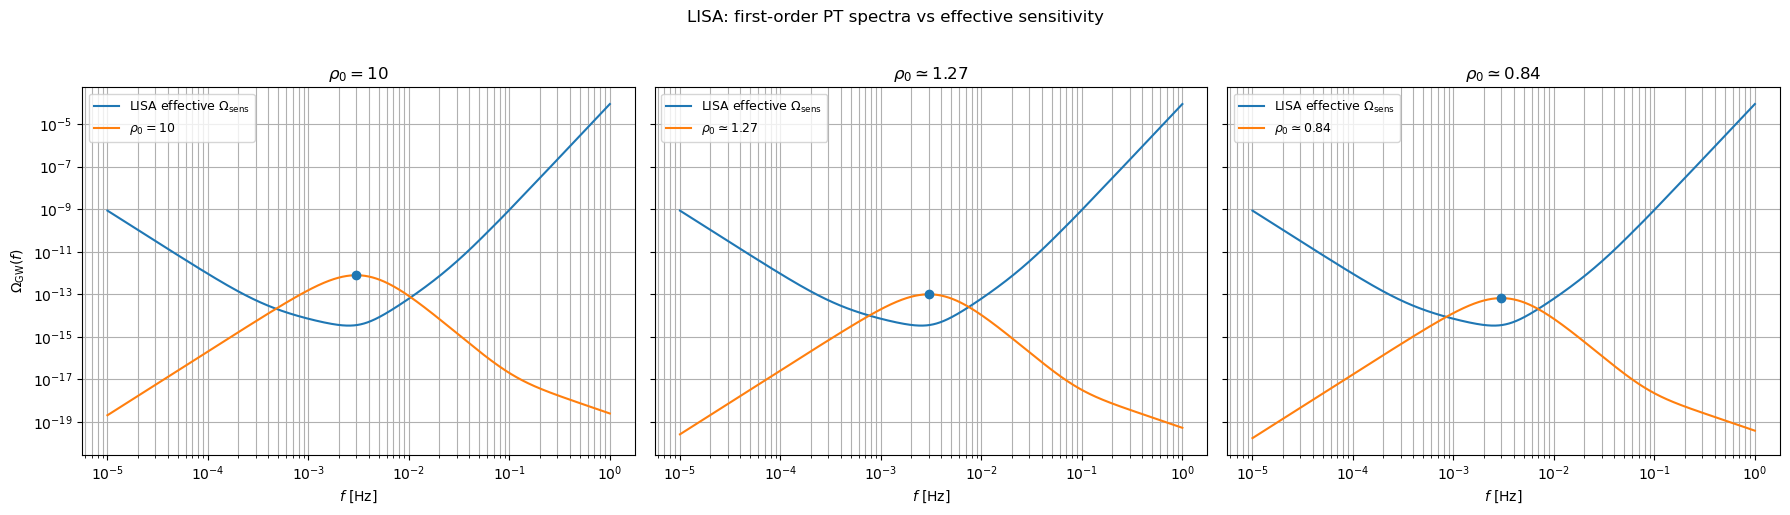

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': '$\\rho_0 = 10$'}, xlabel='$f\\ \\mathrm{[Hz]}$', ylabel='$\\Omega_{\\rm GW}(f)$'>,
        <Axes: title={'center': '$\\rho_0 \\simeq 1.27$'}, xlabel='$f\\ \\mathrm{[Hz]}$'>,
        <Axes: title={'center': '$\\rho_0 \\simeq 0.84$'}, xlabel='$f\\ \\mathrm{[Hz]}$'>],
       dtype=object))

In [7]:
# ------------------------------------------------------------
# LISA fiducials using the solved alpha values
# ------------------------------------------------------------
fiducials = []

for rho_target, alpha_sol, rho_check in alpha_solutions:
    if np.isclose(rho_target, 10.0):
        label = r"$\rho_0 = 10$"
    else:
        label = rf"$\rho_0 \simeq {rho_check:.2f}$"

    fiducials.append(
        dict(
            label=label,
            alpha=alpha_sol,
            beta_over_H=beta_over_H_star,
            Tstar_GeV=Tstar_star,
            vw=vw_star,
            gstar=gstar,
            Uf=Uf,
            zp=zp,
            Gamma=Gamma,
            turb_fraction=turb_fraction,
        )
    )

plot_lisa_three_panels(
    fiducials,
    T_obs_yr=T_obs_yr,
    n_channels=n_channels,
    fmin=fmin_lisa,
    fmax=fmax_lisa,
    nplot=4000,
    gamma_func=None,
    include_confusion=include_confusion,
    show_h2=False,
    title="LISA: first-order PT spectra vs effective sensitivity",
    filename="LISA_amp_vs_freq_threepanel.png",
)

## LISA SNR-grid and Fisher-ellipse plotting functions

Define functions used to make the LISA uncertainty-ellipse figure. The SNR is evaluated on a grid in $\alpha$ and $\beta/H_*$ so that constant-SNR contours can be drawn in the same parameter plane as the Fisher ellipses.

The Fisher ellipses are constructed from the $2\times 2$ covariance matrices in logarithmic parameter space,

$\theta = \left(\ln\alpha,\ \ln(\beta/H_*)\right)$

and then mapped back to the physical parameters $\alpha$ and $\beta/H_*$ for plotting.


In [8]:
# LISA SNR on grid
# ------------------------------------------------------------
def rho_lisa_for_pt_params(
    *,
    alpha: float,
    beta_over_H: float,
    Tstar_GeV: float,
    vw: float,
    T_obs_yr: float = 4.0,
    fmin: float = 1e-5,
    fmax: float = 1.0,
    nfreq: int = 100000,
    n_channels: int = 1,
    include_confusion: bool = False,
    gamma_func=None,
    gstar: float = 106.75,
    Uf=None,
    zp: float = 6.9,
    Gamma: float = 4.0/3.0,
    turb_fraction: float = 0.05,
) -> float:
    
    """
    Compute the LISA SNR for a phase-transition model.

    This is a lightweight wrapper around snr_lisa_crosscorr_from_params,
    used when building SNR contours in the alpha--beta/H_* plane.

    Parameters
    ----------
    alpha : float
        Phase-transition strength parameter.
    beta_over_H : float
        Inverse duration beta/H_*.
    Tstar_GeV : float
        Transition temperature T_* in GeV.
    vw : float
        Bubble wall velocity.
    T_obs_yr : float, optional
        Observation time in years.
    fmin, fmax : float, optional
        Frequency integration limits in Hz.
    nfreq : int, optional
        Number of logarithmically spaced frequency samples.
    n_channels : int, optional
        Effective number of LISA channels.
    include_confusion : bool, optional
        If True, include the Galactic confusion foreground in the LISA PSD.
    gamma_func : callable or None, optional
        Overlap reduction function. If None, gamma(f)=1 is used.
    gstar, Uf, zp, Gamma, turb_fraction : optional
        Source-model parameters passed through to the spectrum model.

    Returns
    -------
    float
        LISA signal-to-noise ratio rho.
    """
    
    
    return snr_lisa_crosscorr_from_params(
        alpha=alpha,
        beta_over_H=beta_over_H,
        Tstar_GeV=Tstar_GeV,
        vw=vw,
        T_obs_yr=T_obs_yr,
        fmin=fmin,
        fmax=fmax,
        nfreq=nfreq,
        n_channels=n_channels,
        include_confusion=include_confusion,
        gstar=gstar,
        Uf=Uf,
        zp=zp,
        Gamma=Gamma,
        turb_fraction=turb_fraction,
        gamma_func=gamma_func,
    )

# ------------------------------------------------------------
# Build ellipse points from a 2x2 covariance matrix
def fisher_ellipse_points(cov2, center, nsig=1.0, npts=700):
    """
    Generate points for a Fisher ellipse from a 2x2 covariance matrix.

    The covariance matrix is assumed to be in logarithmic parameter space,
    with center = (ln alpha, ln(beta/H_*)). The returned arrays are also in
    logarithmic coordinates. They are exponentiated later when plotting in the
    physical alpha--beta/H_* plane.

    Parameters
    ----------
    cov2 : array_like, shape (2, 2)
        Covariance matrix for (ln alpha, ln(beta/H_*)).
    center : tuple or array_like, shape (2,)
        Fiducial point in logarithmic parameter space.
    nsig : float, optional
        Size of the ellipse in units of sigma. For example, nsig=1 gives the
        1-sigma ellipse and nsig=2 gives the 2-sigma ellipse.
    npts : int, optional
        Number of points used to sample the ellipse.

    Returns
    -------
    x : ndarray
        Ellipse coordinates for ln alpha.
    y : ndarray
        Ellipse coordinates for ln(beta/H_*).
    """
    cov2 = np.asarray(cov2, dtype=float)
    vals, vecs = np.linalg.eigh(cov2)
    if np.any(vals <= 0):
        raise ValueError("Covariance not positive definite.")
    t = np.linspace(0, 2*np.pi, npts)
    circle = np.vstack([np.cos(t), np.sin(t)])
    L = vecs @ np.diag(np.sqrt(vals))
    pts = np.array(center).reshape(2, 1) + nsig * (L @ circle)
    return pts[0, :], pts[1, :]


# ------------------------------------------------------------
# Compute the LISA SNR on a grid in (alpha, beta/H_*)
def compute_snr_grid_lisa(
    *,
    Tstar_GeV,
    vw,
    beta_range=(3.0, 1.0e4),
    alpha_range=(1e-4, 1.0),
    n_beta=110,
    n_alpha=90,
    T_obs_yr=4.0,
    fmin=1e-5,
    fmax=1.0,
    nfreq=100000,
    n_channels=1,
    include_confusion=False,
    gamma_func=None,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    """
    Compute the LISA SNR on a grid in alpha and beta/H_*.

    This function is used to generate the constant-SNR contours that are
    overlaid with the Fisher ellipses. The transition temperature T_* and wall
    velocity v_w are held fixed while alpha and beta/H_* are varied over
    logarithmically spaced grids.

    Parameters
    ----------
    Tstar_GeV : float
        Fixed transition temperature T_* in GeV.
    vw : float
        Fixed bubble wall velocity.
    beta_range : tuple of float, optional
        Minimum and maximum beta/H_* values used for the grid.
    alpha_range : tuple of float, optional
        Minimum and maximum alpha values used for the grid.
    n_beta : int, optional
        Number of grid points in beta/H_*.
    n_alpha : int, optional
        Number of grid points in alpha.
    T_obs_yr : float, optional
        Observation time in years.
    fmin, fmax : float, optional
        Frequency integration limits in Hz.
    nfreq : int, optional
        Number of frequency samples used in each SNR calculation.
    n_channels : int, optional
        Effective number of LISA channels.
    include_confusion : bool, optional
        If True, include the Galactic confusion foreground in the LISA PSD.
    gamma_func : callable or None, optional
        Overlap reduction function. If None, gamma(f)=1 is used.
    gstar, Uf, zp, Gamma, turb_fraction : optional
        Source-model parameters passed through to the spectrum model.

    Returns
    -------
    betas : ndarray
        Logarithmically spaced beta/H_* grid.
    alphas : ndarray
        Logarithmically spaced alpha grid.
    R : ndarray, shape (n_alpha, n_beta)
        SNR values on the alpha--beta/H_* grid.
    """
    betas  = np.logspace(np.log10(beta_range[0]), np.log10(beta_range[1]), int(n_beta))
    alphas = np.logspace(np.log10(alpha_range[0]), np.log10(alpha_range[1]), int(n_alpha))
    R = np.zeros((alphas.size, betas.size), dtype=float)

    for ia, a in enumerate(alphas):
        for ib, b in enumerate(betas):
            R[ia, ib] = rho_lisa_for_pt_params(
                alpha=float(a),
                beta_over_H=float(b),
                Tstar_GeV=Tstar_GeV,
                vw=vw,
                T_obs_yr=T_obs_yr,
                fmin=fmin,
                fmax=fmax,
                nfreq=nfreq,
                n_channels=n_channels,
                include_confusion=include_confusion,
                gamma_func=gamma_func,
                gstar=gstar,
                Uf=Uf,
                zp=zp,
                Gamma=Gamma,
                turb_fraction=turb_fraction,
            )

    return betas, alphas, R

# ------------------------------------------------------------
# Draw one panel
def plot_lisa_snr_fisher_on_ax(
    ax,
    *,
    betas,
    alphas,
    R,
    cov2,
    ln_alpha0,
    ln_beta0,
    snr_levels=(0.5, 1, 3, 5, 10),
    ellipse_nsigs=(1.0, 2.0),
    panel_title="",
    snr_alpha=0.7,
    fill_2s_alpha=0.5,
    fill_1s_alpha=0.9,
):
    
    
    """
    Draw one LISA SNR-contour and Fisher-ellipse panel.

    This function overlays Fisher ellipses on top of constant-SNR contours in
    the physical $\alpha$--$\beta/H_*$ parameter plane. The Fisher covariance
    matrix is supplied in logarithmic parameter space,

        theta = (ln alpha, ln(beta/H_*)),

    and the ellipse points are exponentiated before plotting.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis object on which the panel is drawn.
    betas : ndarray
        Grid values for beta/H_*.
    alphas : ndarray
        Grid values for alpha.
    R : ndarray
        SNR grid with shape (len(alphas), len(betas)).
    cov2 : ndarray, shape (2, 2)
        Covariance matrix for (ln alpha, ln(beta/H_*)).
    ln_alpha0 : float
        Fiducial value of ln(alpha).
    ln_beta0 : float
        Fiducial value of ln(beta/H_*).
    snr_levels : tuple of float, optional
        SNR contour levels to draw.
    ellipse_nsigs : tuple of float, optional
        Fisher ellipse sizes to draw, in units of sigma.
    panel_title : str, optional
        Title for the panel.
    snr_alpha : float, optional
        Transparency of the SNR contour lines.
    fill_2s_alpha : float, optional
        Transparency of the 2-sigma ellipse fill.
    fill_1s_alpha : float, optional
        Transparency of the 1-sigma ellipse fill.

    Returns
    -------
    None
        The function modifies the supplied axis in place.
    """
    B, A = np.meshgrid(betas, alphas)

    fill_2s = "#FCA5A5"
    fill_1s = "#93C5FD"

    if 2.0 in ellipse_nsigs:
        xln, yln = fisher_ellipse_points(cov2, center=(ln_alpha0, ln_beta0), nsig=2.0, npts=1200)
        a2 = np.exp(xln)
        b2 = np.exp(yln)
        ax.fill(b2, a2, color=fill_2s, alpha=fill_2s_alpha, zorder=1)
        ax.plot(b2, a2, color="k", linewidth=1.4, zorder=2)

    if 1.0 in ellipse_nsigs:
        xln, yln = fisher_ellipse_points(cov2, center=(ln_alpha0, ln_beta0), nsig=1.0, npts=1200)
        a1 = np.exp(xln)
        b1 = np.exp(yln)
        ax.fill(b1, a1, color=fill_1s, alpha=fill_1s_alpha, zorder=2)
        ax.plot(b1, a1, color="k", linewidth=1.4, zorder=3)

    ax.scatter([np.exp(ln_beta0)], [np.exp(ln_alpha0)],
               s=55, edgecolors="k", linewidths=0.8, zorder=7)

    colors = ("#4C1D95", "#1D4ED8", "#059669", "#DC2626", "#111827")
    ax.contour(
        B, A, R,
        levels=list(snr_levels),
        colors=colors,
        linestyles=["--"] * len(snr_levels),
        linewidths=[1.6] * len(snr_levels),
        alpha=snr_alpha,
        zorder=4
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(betas[0], betas[-1])
    ax.set_ylim(alphas[0], alphas[-1])
    ax.set_title(panel_title)
    ax.grid(True, which="major", alpha=0.20)
    ax.grid(False, which="minor")

## Fisher matrices for the LISA fiducial models

Evaluate the two-parameter Fisher matrix for the three LISA fiducial models used in the ellipse plot. The fixed parameters are $\beta/H_* = 300$, $v_w = 0.8$, and the LISA-band value of $T_*$ obtained from the target sound-wave frequency.

The transition strength $\alpha$ is taken from the target-SNR calibration step above. The results are stored in `fisher_results_lisa`, which is used by the final plotting cell.

In [9]:
# ------------------------------------------------------------
# Fixed LISA-tuned setup
# ------------------------------------------------------------
beta_over_H_star = 300.0
vw_star = 0.8

gstar = 106.75
zp = 6.9
Gamma = 4.0 / 3.0
turb_fraction = 0.05
Uf = None

T_obs_yr = 4.0
fmin_lisa = 1e-5
fmax_lisa = 1.0
nfreq = 100000
n_channels = 1
include_confusion = False
dln = 1e-3

f_sw_target_Hz = 3.0e-3
Tstar_star = solve_Tstar_for_target_fsw(
    f_sw_target_Hz=f_sw_target_Hz,
    beta_over_H=beta_over_H_star,
    vw=vw_star,
    gstar=gstar,
    zp=zp,
)

# Use the alpha values solved in the target-SNR calibration cell.
lisa_fiducials = []

for rho_target, alpha_sol, rho_check in alpha_solutions:
    if np.isclose(rho_target, 10.0):
        label = r"$\rho_0 = 10$"
    else:
        label = rf"$\rho_0 \simeq {rho_check:.2f}$"

    lisa_fiducials.append((alpha_sol, label))

fisher_results_lisa = []

for alpha_star, label in lisa_fiducials:
    ln_alpha0 = np.log(alpha_star)
    ln_beta0 = np.log(beta_over_H_star)
    ln_T0 = np.log(Tstar_star)
    ln_vw0 = np.log(vw_star)

    F2, cov2, sig2, corr2, rho0 = fisher_lisa_lnparams_2par(
        ln_alpha0=ln_alpha0,
        ln_beta_over_H0=ln_beta0,
        ln_Tstar0=ln_T0,
        ln_vw0=ln_vw0,
        T_obs_yr=T_obs_yr,
        fmin=fmin_lisa,
        fmax=fmax_lisa,
        nfreq=nfreq,
        n_channels=n_channels,
        dln=dln,
        include_confusion=include_confusion,
        gstar=gstar,
        Uf=Uf,
        zp=zp,
        Gamma=Gamma,
        turb_fraction=turb_fraction,
    )

    fisher_results_lisa.append({
        "label": label,
        "alpha0": alpha_star,
        "beta0": beta_over_H_star,
        "ln_alpha0": ln_alpha0,
        "ln_beta0": ln_beta0,
        "cov2": cov2,
        "rho0": rho0,
        "sig2": sig2,
        "corr2": corr2,
    })

    print(label)
    print("  alpha0 =", alpha_star)
    print("  beta/H* =", beta_over_H_star)
    print("  T* [GeV] =", Tstar_star)
    print("  rho0 =", rho0)
    print("  sigmas =", sig2)
    print("  corr =\n", corr2)
    print()

$\rho_0 = 10$
  alpha0 = 0.05865407884189459
  beta/H* = 300.0
  T* [GeV] = 128.86141887540026
  rho0 = 9.994234078680995
  sigmas = [0.04261995 0.11283797]
  corr =
 [[1.         0.77560701]
 [0.77560701 1.        ]]

$\rho_0 \simeq 1.27$
  alpha0 = 0.03397026649619214
  beta/H* = 300.0
  T* [GeV] = 128.86141887540026
  rho0 = 1.2697231496792476
  sigmas = [0.32599429 0.88818417]
  corr =
 [[1.         0.77561677]
 [0.77561677 1.        ]]

$\rho_0 \simeq 0.84$
  alpha0 = 0.030496647444565445
  beta/H* = 300.0
  T* [GeV] = 128.86141887540026
  rho0 = 0.8395097504771276
  sigmas = [0.49101167 1.34334725]
  corr =
 [[1.         0.77561941]
 [0.77561941 1.        ]]



## LISA SNR contours and Fisher ellipses

Compute the LISA SNR grid in the $(\beta/H_*, \alpha)$ plane and use it to draw constant-SNR contours. 

Overlays the Fisher ellipses for the three LISA fiducial models.

The result is a single three-panel figure 

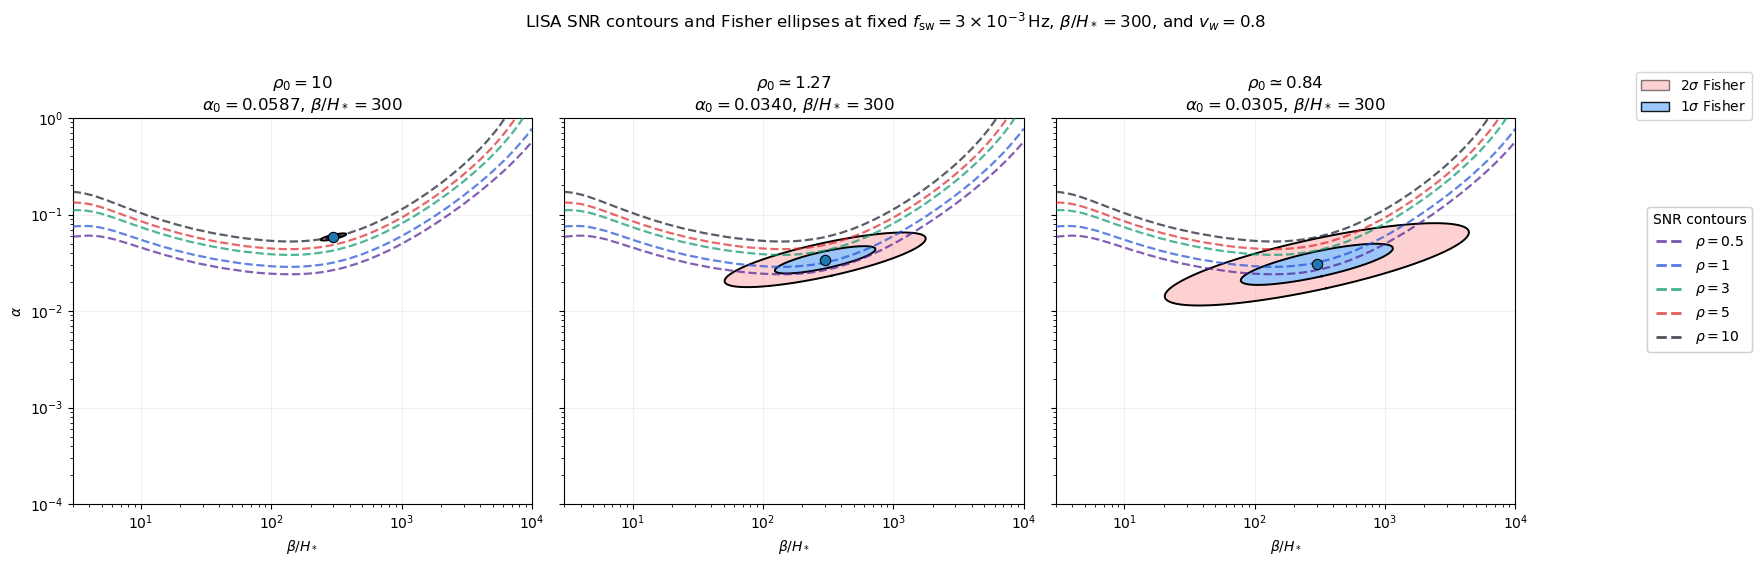

In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# Build LISA SNR grid once
betas, alphas, R = compute_snr_grid_lisa(
    Tstar_GeV=Tstar_star,
    vw=vw_star,
    beta_range=(3.0, 1.0e4),
    alpha_range=(1e-4, 1.0),
    n_beta=110,
    n_alpha=90,
    T_obs_yr=T_obs_yr,
    fmin=fmin_lisa,
    fmax=fmax_lisa,
    nfreq=nfreq,
    n_channels=n_channels,
    include_confusion=include_confusion,
    gstar=gstar,
    Uf=Uf,
    zp=zp,
    Gamma=Gamma,
    turb_fraction=turb_fraction,
)

# ------------------------------------------------------------
# Plot all three LISA Fisher ellipses
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

for ax, res in zip(axes, fisher_results_lisa):
    panel_title = res["label"] + "\n" + rf"$\alpha_0={res['alpha0']:.4f}$, $\beta/H_*={res['beta0']:.0f}$"

    plot_lisa_snr_fisher_on_ax(
        ax,
        betas=betas,
        alphas=alphas,
        R=R,
        cov2=res["cov2"],
        ln_alpha0=res["ln_alpha0"],
        ln_beta0=res["ln_beta0"],
        snr_levels=(0.5, 1, 3, 5, 10),
        ellipse_nsigs=(1.0, 2.0),
        panel_title=panel_title,
        snr_alpha=0.7,
        fill_2s_alpha=0.5,
        fill_1s_alpha=0.9,
    )

axes[0].set_ylabel(r"$\alpha$")
for ax in axes:
    ax.set_xlabel(r"$\beta/H_*$")

snr_levels = (0.5, 1, 3, 5, 10)
colors = ("#4C1D95", "#1D4ED8", "#059669", "#DC2626", "#111827")

snr_handles = [
    Line2D([0], [0], color=c, lw=2.0, alpha=0.7, linestyle="--", label=rf"$\rho={lvl:g}$")
    for c, lvl in zip(colors, snr_levels)
]

fill_2s = "#FCA5A5"
fill_1s = "#93C5FD"

fisher_handles = [
    Patch(facecolor=fill_2s, edgecolor="k", alpha=0.5, label=r"$2\sigma$ Fisher"),
    Patch(facecolor=fill_1s, edgecolor="k", alpha=0.9, label=r"$1\sigma$ Fisher"),
]

fig.legend(handles=fisher_handles, loc="upper right", bbox_to_anchor=(0.98, 0.92), frameon=True)
fig.legend(handles=snr_handles, loc="center right", bbox_to_anchor=(0.98, 0.53), frameon=True, title="SNR contours")


fig.legend(handles=snr_handles, loc="center right", bbox_to_anchor=(0.98, 0.53), frameon=True, title="SNR contours")

fig.suptitle(
    r"LISA SNR contours and Fisher ellipses at fixed $f_{\rm sw}=3\times10^{-3}\,{\rm Hz}$, $\beta/H_*=300$, and $v_w=0.8$",
    y=1.02
)
fig.tight_layout(rect=[0, 0, 0.86, 1])
plt.savefig("lisa_fisher_compare_3panel.png", dpi=300, bbox_inches="tight")
plt.show()